In [2]:
# Question_1
n=int(input("Enter Number of Variables in Linear Variables:"))
Matrix=[]
for i in range(n):
    row=[]
    for j in range (n+1):
        a=float(input(f"Enter the Element: [{i}][{j}]"))
        row.append(a)
    Matrix.append(row)

for k in Matrix:
 
    print(*k)
#forwanrd Elimnation

for i in range (n):
    for i in range (n):
        for j in range(i+1,n):
            Ratio=Matrix[j][i] / Matrix[i][i]
        for k in range (n+1):
            Matrix[j][k]=Matrix[j][k]-Ratio*Matrix[i][k]
print("\nUpper Triangular Matrix:")
for i in Matrix:
    print(*i)  
# Back Substution
x = [0] * n

x[n - 1] = Matrix[n - 1][n] / Matrix[n - 1][n - 1]

for i in range(n - 2, -1, -1):
    s = 0

    for j in range(i + 1, n):
        s = s + Matrix[i][j] * x[j]

    x[i] = (Matrix[i][n] - s) / Matrix[i][i]
print("Solution:")
for i in range(n):
    print("x", i+1, "=", round(x[i],4))





Enter Number of Variables in Linear Variables: 3
Enter the Element: [0][0] 2
Enter the Element: [0][1] 4
Enter the Element: [0][2] 1
Enter the Element: [0][3] 5
Enter the Element: [1][0] 2
Enter the Element: [1][1] 7
Enter the Element: [1][2] 3
Enter the Element: [1][3] 2
Enter the Element: [2][0] 9
Enter the Element: [2][1] 6
Enter the Element: [2][2] 5
Enter the Element: [2][3] 1


2.0 4.0 1.0 5.0
2.0 7.0 3.0 2.0
9.0 6.0 5.0 1.0

Upper Triangular Matrix:
2.0 4.0 1.0 5.0
2.0 7.0 3.0 2.0
72.9278020520132 0.0 492.92737038020897 -1854.0564258666118
Solution:
x 1 = 0.5852
x 2 = 1.8977
x 3 = -3.7613


In [27]:
#Question_2
def print_matrix(matrix, label="Matrix"):
    print(f"\n--- {label} ---")
    for row in matrix:
        formatted_row = [f"{val:10.4f}" for val in row[:-1]]
        formatted_b = f"| {row[-1]:10.4f}"
        print("  ".join(formatted_row) + "  " + formatted_b)
    print()

def gaussian_elimination_pivot_pure(A, b):
    n = len(b)
    
    
    Ab = [list(map(float, A[i])) + [float(b[i])] for i in range(n)]
    
    print_matrix(Ab, "Initial Augmented Matrix [A | b]")
    
    
    for i in range(n):
        # Find pivot (row with max absolute value in column i)
        pivot_row = i
        max_val = abs(Ab[i][i])
        for r in range(i + 1, n):
            if abs(Ab[r][i]) > max_val:
                max_val = abs(Ab[r][i])
                pivot_row = r
                
        
        if abs(Ab[pivot_row][i]) < 1e-12:
            raise ValueError("Matrix is singular or nearly singular; no unique solution exists.")
            
        
        if pivot_row != i:
            Ab[i], Ab[pivot_row] = Ab[pivot_row], Ab[i]
            
        
        for j in range(i + 1, n):
            factor = Ab[j][i] / Ab[i][i]
            for k in range(i, n + 1):
                Ab[j][k] -= factor * Ab[i][k]
                
    print_matrix(Ab, "Matrix After Forward Elimination (Upper Triangular Form)")
    
    
    x = [0.0] * n
    for i in range(n - 1, -1, -1):
        sum_ax = sum(Ab[i][j] * x[j] for j in range(i + 1, n))
        x[i] = (Ab[i][n] - sum_ax) / Ab[i][i]
        
    
    print("--- Matrix State After Back Substitution ---")
    for i in range(n):
        row_str = "  ".join([f"{Ab[i][j]:10.4f}" for j in range(n)])
        print(f"{row_str}  | {Ab[i][n]:10.4f}  =>  x[{i+1}] = {x[i]:10.4f}")
    print()

    return x

def get_user_inputs():
    print("=== Pure Python Gaussian Elimination Solver ===")
    
    while True:
        try:
            n = int(input("Enter number of equations/variables (n): "))
            if n > 0:
                break
            print("Enter a positive integer.")
        except ValueError:
            print("Invalid input.")

    print(f"\nEnter row by row ({n} numbers separated by spaces):")
    A = []
    for i in range(n):
        while True:
            try:
                row = list(map(float, input(f"Row {i + 1}: ").split()))
                if len(row) != n:
                    print(f"Expected {n} numbers, got {len(row)}.")
                    continue
                A.append(row)
                break
            except ValueError:
                print("Invalid input.")

    print(f"\nEnter {n} values for vector b (separated by spaces):")
    b = []
    while len(b) < n:
        try:
            vals = list(map(float, input(f"Vector b ({n - len(b)} needed): ").split()))
            b.extend(vals)
            if len(b) > n:
                print("Too many values entered. Re-enter vector b.")
                b = []
        except ValueError:
            print("Invalid input.")

    return A, b

if __name__ == "__main__":
    A, b = get_user_inputs()
    try:
        sol = gaussian_elimination_pivot_pure(A, b)
        print("=" * 40)
        print("FINAL SOLUTION:")
        for i, val in enumerate(sol):
            print(f"x[{i + 1}] = {val:.6f}")
        print("=" * 40)
    except ValueError as err:
        print(f"\nError: {err}")

=== Pure Python Gaussian Elimination Solver ===


Enter number of equations/variables (n):  3



Enter row by row (3 numbers separated by spaces):


Row 1:  0 2 1
Row 2:  1 -2 -3
Row 3:  -1 1 2



Enter 3 values for vector b (separated by spaces):


Vector b (3 needed):  -8 0 3



--- Initial Augmented Matrix [A | b] ---
    0.0000      2.0000      1.0000  |    -8.0000
    1.0000     -2.0000     -3.0000  |     0.0000
   -1.0000      1.0000      2.0000  |     3.0000


--- Matrix After Forward Elimination (Upper Triangular Form) ---
    1.0000     -2.0000     -3.0000  |     0.0000
    0.0000      2.0000      1.0000  |    -8.0000
    0.0000      0.0000     -0.5000  |    -1.0000

--- Matrix State After Back Substitution ---
    1.0000     -2.0000     -3.0000  |     0.0000  =>  x[1] =    -4.0000
    0.0000      2.0000      1.0000  |    -8.0000  =>  x[2] =    -5.0000
    0.0000      0.0000     -0.5000  |    -1.0000  =>  x[3] =     2.0000

FINAL SOLUTION:
x[1] = -4.000000
x[2] = -5.000000
x[3] = 2.000000


In [1]:
# Question_3
# 76 * I1 - 25 * I2 - 50 * I3 = 10
#-25 * I1 + 56 * I2 - 1 * I3 = 0
#-50 * I1 - 1 * I2 + 106 * I3 = 0
# Gauss-Jordan Elimination Method

n = int(input("Enter number of variables: "))


A = []

print("Enter the augmented matrix row by row:")

for i in range(n):
    row = list(map(float, input(f"Row {i+1}: ").split()))
    
    if len(row) != n + 1:
        print("Error: Enter exactly", n + 1, "elements.")
        exit()
        
    A.append(row)


for i in range(n):

    
    max_row = i
    for j in range(i + 1, n):
        if abs(A[j][i]) > abs(A[max_row][i]):
            max_row = j

    
    A[i], A[max_row] = A[max_row], A[i]

    
    if abs(A[i][i]) < 1e-12:
        print("No unique solution exists.")
        exit()

    
    pivot = A[i][i]

    for j in range(n + 1):
        A[i][j] /= pivot

    
    for k in range(n):
        if k != i:
            factor = A[k][i]

            for j in range(n + 1):
                A[k][j] -= factor * A[i][j]


print("\nReduced Row Echelon Form:")
for row in A:
    print(["{:.4f}".format(x) for x in row])


print("\nSolution:")
for i in range(n):
    print(f"x{i + 1} = {A[i][n]:.4f}")





Enter number of variables:  3


Enter the augmented matrix row by row:


Row 1:  76 -25 -50 10
Row 2:  -25 56 -1 0
Row 3:  -50 -1 106 0



Reduced Row Echelon Form:
['1.0000', '0.0000', '0.0000', '0.2449']
['0.0000', '1.0000', '0.0000', '0.1114']
['0.0000', '0.0000', '1.0000', '0.1166']

Solution:
x1 = 0.2449
x2 = 0.1114
x3 = 0.1166


Enter initial number of nuclei N0:  1000
Enter decay constant lambda:  1
Enter time step dt:  2
Enter order of matrix (number of equations):  50



Time		Numerical N(t)	Exact N(t)
2.0000		333.333333	135.335283
4.0000		111.111111	18.315639
6.0000		37.037037	2.478752
8.0000		12.345679	0.335463
10.0000		4.115226	0.045400
12.0000		1.371742	0.006144
14.0000		0.457247	0.000832
16.0000		0.152416	0.000113
18.0000		0.050805	0.000015
20.0000		0.016935	0.000002
22.0000		0.005645	0.000000
24.0000		0.001882	0.000000
26.0000		0.000627	0.000000
28.0000		0.000209	0.000000
30.0000		0.000070	0.000000
32.0000		0.000023	0.000000
34.0000		0.000008	0.000000
36.0000		0.000003	0.000000
38.0000		0.000001	0.000000
40.0000		0.000000	0.000000
42.0000		0.000000	0.000000
44.0000		0.000000	0.000000
46.0000		0.000000	0.000000
48.0000		0.000000	0.000000
50.0000		0.000000	0.000000
52.0000		0.000000	0.000000
54.0000		0.000000	0.000000
56.0000		0.000000	0.000000
58.0000		0.000000	0.000000
60.0000		0.000000	0.000000
62.0000		0.000000	0.000000
64.0000		0.000000	0.000000
66.0000		0.000000	0.000000
68.0000		0.000000	0.000000
70.0000		0.000000	0.000000
72.0000		0.000000

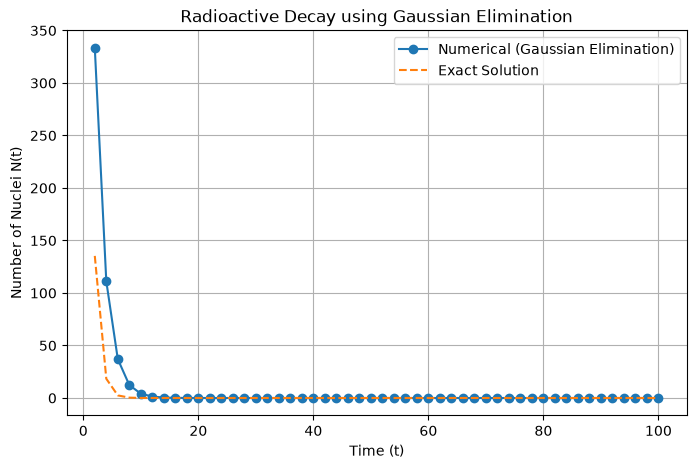

In [4]:
# Question_4
import numpy as np
import matplotlib.pyplot as plt


N0 = float(input("Enter initial number of nuclei N0: "))
lam = float(input("Enter decay constant lambda: "))
dt = float(input("Enter time step dt: "))

order = int(input("Enter order of matrix (number of equations): "))

T = order * dt



n = order
A = np.zeros((n, n + 1))

factor = 1 + lam * dt

A[0, 0] = factor
A[0, n] = N0


for i in range(1, n):
    A[i, i - 1] = -1
    A[i, i] = factor


for i in range(n):


    max_row = i + np.argmax(abs(A[i:, i]))


    if max_row != i:
        A[[i, max_row]] = A[[max_row, i]]


    if abs(A[i, i]) < 1e-12:
        print("Zero pivot encountered!")
        break

    for j in range(i + 1, n):

        multiplier = A[j, i] / A[i, i]

        for k in range(i, n + 1):
            A[j, k] -= multiplier * A[i, k]


N_values = np.zeros(n)

for i in range(n - 1, -1, -1):

    sum_value = 0

    for j in range(i + 1, n):
        sum_value += A[i, j] * N_values[j]

    N_values[i] = (A[i, n] - sum_value) / A[i, i]



time = np.array([(i + 1) * dt for i in range(n)])


exact = N0 * np.exp(-lam * time)


print("\nTime\t\tNumerical N(t)\tExact N(t)")


for t, numerical, exact_value in zip(time, N_values, exact):
    print(f"{t:.4f}\t\t{numerical:.6f}\t{exact_value:.6f}")



plt.figure(figsize=(8, 5))

plt.plot(
    time,
    N_values,
    'o-',
    label="Numerical (Gaussian Elimination)"
)

plt.plot(
    time,
    exact,
    '--',
    label="Exact Solution"
)

plt.xlabel("Time (t)")
plt.ylabel("Number of Nuclei N(t)")
plt.title("Radioactive Decay using Gaussian Elimination")

plt.grid(True)
plt.legend()

plt.show()

In [5]:
# Question_5

import numpy as np


hbar = 1.054571817e-34

E = float(input("Enter energy E (J): "))
dt = float(input("Enter time step dt: "))
T = float(input("Enter total time T: "))


psi = complex(input("Enter initial wave function (e.g. 1+0j): "))

n = int(T / dt)

print("\nTime\t\tReal(psi)\tImag(psi)\t|psi|")

for i in range(n + 1):

    t = i * dt

    print(f"{t:.4e}\t{psi.real:.6e}\t"
          f"{psi.imag:.6e}\t{abs(psi):.6e}")

    if i == n:
        break

    

    A = np.array([[complex(0, hbar) - E * dt,
                   complex(0, hbar) * psi]], dtype=complex)

    
    A[0] = A[0] / A[0, 0]

    psi = A[0, 1]

Enter energy E (J):  10
Enter time step dt:  1
Enter total time T:  10
Enter initial wave function (e.g. 1+0j):  1+2j



Time		Real(psi)	Imag(psi)	|psi|
0.0000e+00	1.000000e+00	2.000000e+00	2.236068e+00
1.0000e+00	2.109144e-35	-1.054572e-35	2.358094e-35
2.0000e+00	-1.112122e-70	-2.224243e-70	2.486780e-70
3.0000e+00	-2.345624e-105	1.172812e-105	2.622488e-105
4.0000e+00	1.236815e-140	2.473629e-140	2.765602e-140
5.0000e+00	2.608620e-175	-1.304310e-175	2.916526e-175
6.0000e+00	-1.375489e-210	-2.750977e-210	3.075686e-210
7.0000e+00	-2.901103e-245	1.450551e-245	3.243532e-245
8.0000e+00	1.529711e-280	3.059421e-280	3.420537e-280
9.0000e+00	3.226379e-315	-1.613190e-315	3.607202e-315
1.0000e+01	-0.000000e+00	-0.000000e+00	0.000000e+00


Enter energy E (J):  1
Enter time step dt:  0.01
Enter total time T:  1
Enter initial wave function (e.g. 1+0j):  1+1j



Time		Real(psi)	Imag(psi)
0.0000e+00	1.000000e+00	1.000000e+00
1.0000e-02	-1.000000e+00	-1.000000e+00
2.0000e-02	1.000000e+00	1.000000e+00
3.0000e-02	-1.000000e+00	-1.000000e+00
4.0000e-02	1.000000e+00	1.000000e+00
5.0000e-02	-1.000000e+00	-1.000000e+00
6.0000e-02	1.000000e+00	1.000000e+00
7.0000e-02	-1.000000e+00	-1.000000e+00
8.0000e-02	1.000000e+00	1.000000e+00
9.0000e-02	-1.000000e+00	-1.000000e+00
1.0000e-01	1.000000e+00	1.000000e+00
1.1000e-01	-1.000000e+00	-1.000000e+00
1.2000e-01	1.000000e+00	1.000000e+00
1.3000e-01	-1.000000e+00	-1.000000e+00
1.4000e-01	1.000000e+00	1.000000e+00
1.5000e-01	-1.000000e+00	-1.000000e+00
1.6000e-01	1.000000e+00	1.000000e+00
1.7000e-01	-1.000000e+00	-1.000000e+00
1.8000e-01	1.000000e+00	1.000000e+00
1.9000e-01	-1.000000e+00	-1.000000e+00
2.0000e-01	1.000000e+00	1.000000e+00
2.1000e-01	-1.000000e+00	-1.000000e+00
2.2000e-01	1.000000e+00	1.000000e+00
2.3000e-01	-1.000000e+00	-1.000000e+00
2.4000e-01	1.000000e+00	1.000000e+00
2.5000e-01	-1.000000e+00

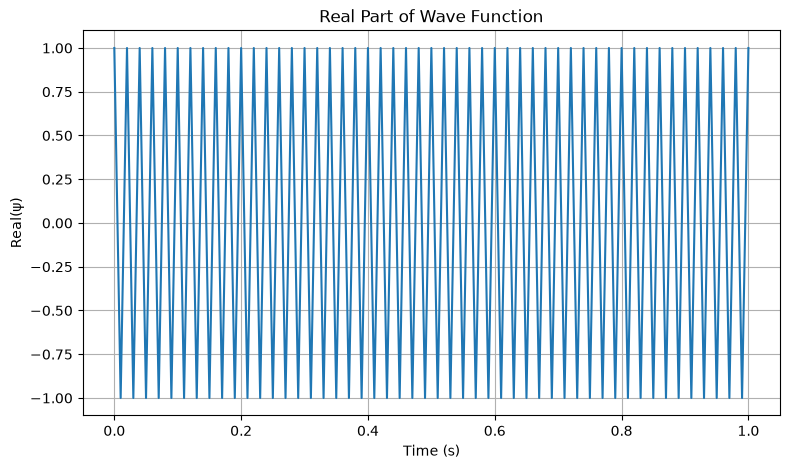

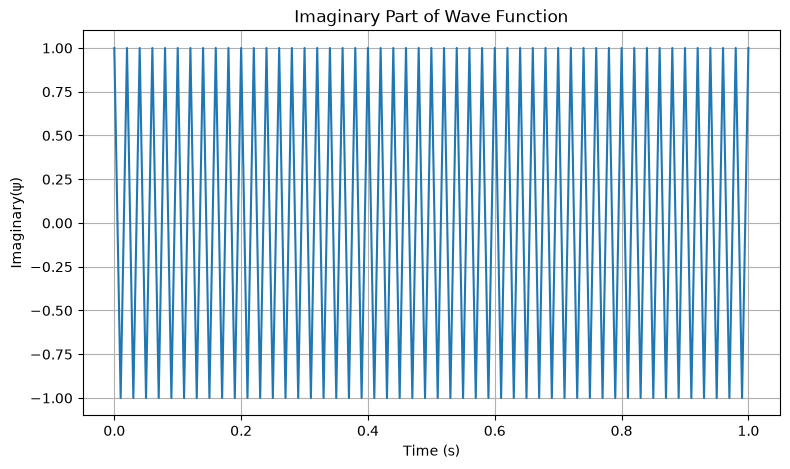

In [8]:
# Question_5


import numpy as np
import matplotlib.pyplot as plt

hbar = 1.054571817e-34


E = float(input("Enter energy E (J): "))
dt = float(input("Enter time step dt: "))
T = float(input("Enter total time T: "))

psi = complex(input("Enter initial wave function (e.g. 1+0j): "))

n = int(T / dt)


time = []
real_psi = []
imag_psi = []


time.append(0)
real_psi.append(psi.real)
imag_psi.append(psi.imag)

print("\nTime\t\tReal(psi)\tImag(psi)")

print(f"{0:.4e}\t{psi.real:.6e}\t{psi.imag:.6e}")



for i in range(1, n + 1):

    t = i * dt

    \

    alpha = 1j * E * dt / (2 * hbar)


    A = np.array([
        [1 + alpha, (1 - alpha) * psi]
    ], dtype=complex)


    A[0] = A[0] / A[0, 0]


    psi = A[0, 1]


    time.append(t)
    real_psi.append(psi.real)
    imag_psi.append(psi.imag)

    print(f"{t:.4e}\t{psi.real:.6e}\t{psi.imag:.6e}")



plt.figure(figsize=(9, 5))

plt.plot(time, real_psi)

plt.xlabel("Time (s)")
plt.ylabel("Real(ψ)")
plt.title("Real Part of Wave Function")

plt.grid()
plt.show()




plt.figure(figsize=(9, 5))

plt.plot(time, imag_psi)

plt.xlabel("Time (s)")
plt.ylabel("Imaginary(ψ)")
plt.title("Imaginary Part of Wave Function")

plt.grid()
plt.show()